In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [3]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


C:\Users\Matth\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [25]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

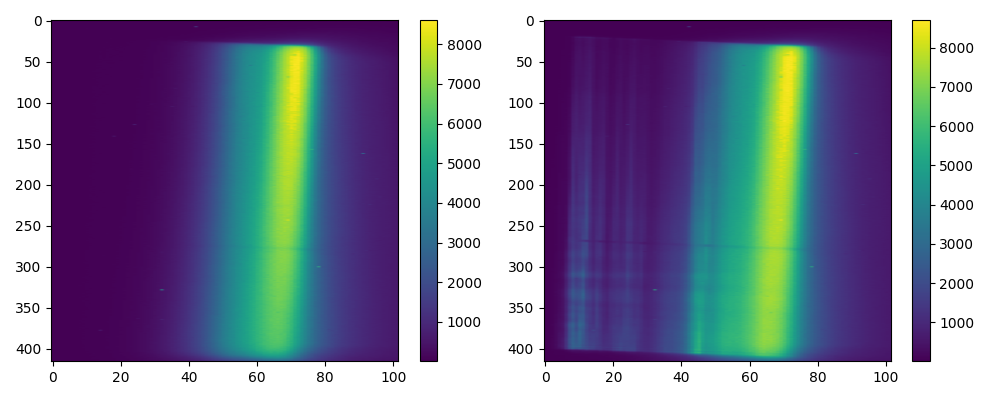

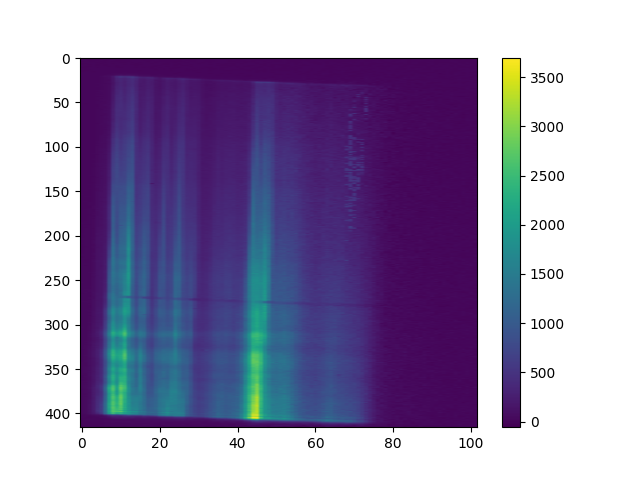

In [24]:
bgPath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step2\\20250123.rimas.0090.HK.fits"
dirtySpecPath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step2\\20250123.rimas.0091.HK.fits"
bg = fits.open(bgPath)[0].data
bg[np.isnan(bg)] = -1
dirtySpec = fits.open(dirtySpecPath)[0].data
dirtySpec[np.isnan(dirtySpec)] = -1

Util.flipY(bg)
Util.flipY(dirtySpec)

bg = Util.cropImage(bg, 83, 1098, 416, 102)
dirtySpec = Util.cropImage(dirtySpec, 83, 1098, 416, 102)

fig, ax = plt.subplots(1,2, figsize=(10,4))
img1 = ax[0].imshow(bg, vmin=np.min(bg), vmax=np.max(bg))
fig.colorbar(img1)
ax[0].set_aspect("auto")
img2 = ax[1].imshow(dirtySpec, vmin=np.min(dirtySpec), vmax=np.max(dirtySpec))
fig.colorbar(img2)
ax[1].set_aspect("auto")
fig.tight_layout()

specImg = dirtySpec-bg
fig2, ax2 = plt.subplots()
img = ax2.imshow(specImg, vmin=np.min(specImg), vmax=np.max(specImg))
fig2.colorbar(img)
ax2.set_aspect("auto")

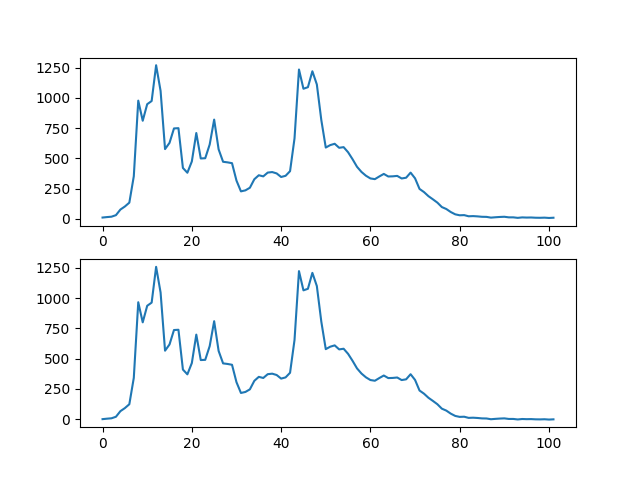

In [34]:
linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Kr"])

spec = Spec1D.convert2Dto1D(specImg, 150, 200)
continuum = Spec1D.continuum(spec, thresh=1, debug=False)
contSub = spec - continuum(np.arange(0, len(spec)))

fig, ax = plt.subplots(2,1)
ax[0].plot(spec)
ax[1].plot(contSub)

14338.763819095477 3.6122448979591835


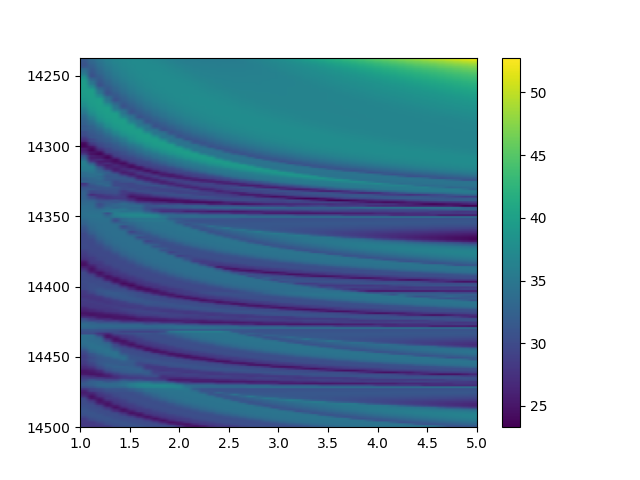

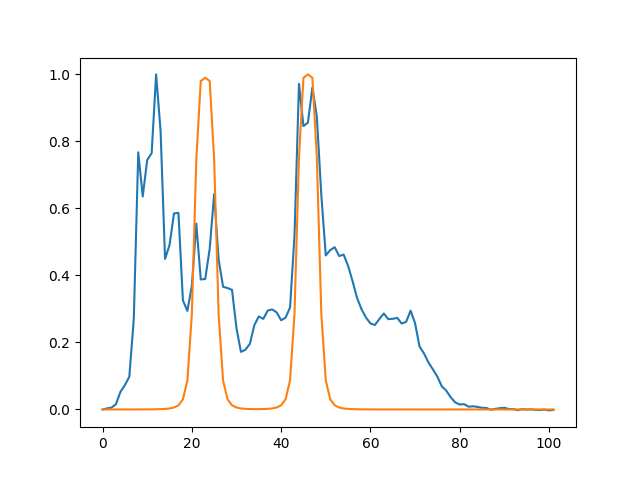

In [63]:
w, a = Spec1D.calcLinearFit(contSub, lines, 14237, 14500, 1, 5, resW=200, resS=50)
print(w, a)